# COVID19 Worldwide Testing Data

This notebook is refactored to answer one question:

**Which countries have reported the highest number of positive cases in relation to the number of tests conducted?**

### Analysis Flow
- Load `tested_worldwide.csv` and inspect coverage
- Clean fields and standardize country/date records
- Build positivity metrics: cumulative and daily
- Rank countries by positivity ratio (`positive / total_tested`)
- Visualize top countries and supporting context
- Export ranked outputs for reproducibility

## 1) Import Libraries and Configure Environment

Import analysis libraries and define display/plot style.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

# Optional plotting library
try:
    import plotly.express as px
    PLOTLY_AVAILABLE = True
except Exception:
    PLOTLY_AVAILABLE = False

# Display + plotting config
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)

print("Libraries imported successfully.")
print(f"Plotly available: {PLOTLY_AVAILABLE}")

Libraries imported successfully.
Plotly available: True


## 2) Load Dataset

Load local worldwide testing data and parse dates.

In [2]:
DATA_PATH = Path(r"c:\Users\O25002\projects\hackathon\hackathon-python-data-eng-MixCodes\tested_worldwide.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Input file not found: {DATA_PATH}")

df_raw = pd.read_csv(DATA_PATH, parse_dates=["Date"])
source_used = str(DATA_PATH)

print(f"Source used: {source_used}")
print(f"Rows: {df_raw.shape[0]:,} | Columns: {df_raw.shape[1]:,}")
df_raw.head()

Source used: c:\Users\O25002\projects\hackathon\hackathon-python-data-eng-MixCodes\tested_worldwide.csv
Rows: 27,641 | Columns: 12


,Date,Country_Region,Province_State,positive,active,hospitalized,hospitalizedCurr,recovered,death,total_tested,daily_tested,daily_positive
0,2020-01-16,Iceland,All States,3.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-01-17,Iceland,All States,4.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0000
2,2020-01-18,Iceland,All States,7.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0000
3,2020-01-20,South Korea,All States,1.0000,NaN,NaN,NaN,NaN,NaN,4.0000,NaN,NaN
4,2020-01-22,United States,All States,0.0000,NaN,NaN,NaN,NaN,0.0000,0.0000,NaN,NaN


In [4]:
# 1.1 Import already completed above; display first 5 rows
print("1.1 First 5 rows of the dataframe")
display(df_raw.head())

# 1.2 Display number of rows and columns
rows, cols = df_raw.shape
print(f"1.2 Dataframe shape -> Rows: {rows:,}, Columns: {cols:,}")

# 1.3 Display data types of each column
print("\n1.3 Data types of each column")
display(df_raw.dtypes.to_frame(name="data_type"))

# 1.4 Display number of missing values in each column
print("\n1.4 Missing values per column")
display(df_raw.isna().sum().to_frame(name="missing_values"))

# 1.5 Display number of unique values in each column
print("\n1.5 Unique values per column")
display(df_raw.nunique().to_frame(name="unique_values"))

1.1 First 5 rows of the dataframe


,Date,Country_Region,Province_State,positive,active,hospitalized,hospitalizedCurr,recovered,death,total_tested,daily_tested,daily_positive
0,2020-01-16,Iceland,All States,3.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-01-17,Iceland,All States,4.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0000
2,2020-01-18,Iceland,All States,7.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0000
3,2020-01-20,South Korea,All States,1.0000,NaN,NaN,NaN,NaN,NaN,4.0000,NaN,NaN
4,2020-01-22,United States,All States,0.0000,NaN,NaN,NaN,NaN,0.0000,0.0000,NaN,NaN


1.2 Dataframe shape -> Rows: 27,641, Columns: 12

1.3 Data types of each column


,data_type
Date,datetime64[us]
Country_Region,str
Province_State,str
positive,float64
active,float64
hospitalized,float64
hospitalizedCurr,float64
recovered,float64
death,float64
total_tested,float64



1.4 Missing values per column


,missing_values
Date,0
Country_Region,0
Province_State,0
positive,4242
active,9833
hospitalized,19231
hospitalizedCurr,13080
recovered,9626
death,4010
total_tested,912



1.5 Unique values per column


,unique_values
Date,297
Country_Region,147
Province_State,81
positive,14998
active,9554
hospitalized,4862
hospitalizedCurr,2904
recovered,9183
death,5641
total_tested,23610


## 3) Data Cleaning (Tasks 2.1 to 2.5)

Apply required preprocessing steps before positivity-rate analysis.

In [5]:
df = df_raw.copy()

# 2.1 Drop columns not needed for this analysis
needed_cols = ["Date", "Country_Region", "positive", "total_tested", "daily_tested", "daily_positive"]
df = df[needed_cols].copy()
print("2.1 Columns kept:", list(df.columns))

# 2.2 Rename columns for readability and consistency
df = df.rename(columns={
    "Date": "date",
    "Country_Region": "country",
    "positive": "cumulative_positive",
    "total_tested": "cumulative_tested",
    "daily_tested": "daily_tested",
    "daily_positive": "daily_positive"
})
print("2.2 Renamed columns:", list(df.columns))

# 2.3 Drop rows with missing values in the analysis columns
before_rows = len(df)
df = df.dropna(subset=["date", "country", "cumulative_positive", "cumulative_tested", "daily_tested", "daily_positive"]).copy()
after_rows = len(df)
print(f"2.3 Rows removed due to missing values: {before_rows - after_rows:,}")
print(f"2.3 Rows remaining: {after_rows:,}")

# 2.4 Convert data types to appropriate types
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["country"] = df["country"].astype("string").str.strip()

numeric_cols = ["cumulative_positive", "cumulative_tested", "daily_tested", "daily_positive"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Remove invalid numeric values after conversion
for col in numeric_cols:
    df.loc[df[col] < 0, col] = np.nan

df = df.dropna(subset=["date", "country"] + numeric_cols).copy()

# Keep only logically valid cumulative relationship
df = df[df["cumulative_positive"] <= df["cumulative_tested"]].copy()

# Use integer type after all filtering
df["cumulative_positive"] = df["cumulative_positive"].astype("int64")
df["cumulative_tested"] = df["cumulative_tested"].astype("int64")
df["daily_tested"] = df["daily_tested"].astype("int64")
df["daily_positive"] = df["daily_positive"].astype("int64")

# Compatibility aliases for downstream analysis
df["positive"] = df["cumulative_positive"]
df["total_tested"] = df["cumulative_tested"]

print("2.4 Data types after conversion:")
display(df.dtypes.to_frame(name="data_type"))

# 2.5 Display the number of missing values in each column
print("2.5 Missing values in each column after cleaning:")
display(df.isna().sum().to_frame(name="missing_values"))

display(df.head())

2.1 Columns kept: ['Date', 'Country_Region', 'positive', 'total_tested', 'daily_tested', 'daily_positive']
2.2 Renamed columns: ['date', 'country', 'cumulative_positive', 'cumulative_tested', 'daily_tested', 'daily_positive']
2.3 Rows removed due to missing values: 4,906
2.3 Rows remaining: 22,735
2.4 Data types after conversion:


,data_type
date,datetime64[us]
country,string
cumulative_positive,int64
cumulative_tested,int64
daily_tested,int64
daily_positive,int64
positive,int64
total_tested,int64


2.5 Missing values in each column after cleaning:


,missing_values
date,0
country,0
cumulative_positive,0
cumulative_tested,0
daily_tested,0
daily_positive,0
positive,0
total_tested,0


,date,country,cumulative_positive,cumulative_tested,daily_tested,daily_positive,positive,total_tested
7,2020-01-23,United States,0,0,0,0,0,0
8,2020-01-23,United States,0,0,0,0,0,0
9,2020-01-23,United States,0,0,0,0,0,0
10,2020-01-24,South Korea,2,27,5,0,2,27
11,2020-01-24,United States,0,0,0,0,0,0


In [7]:
# 3.1 Create a dataframe with total positive cases per country
country_positive_totals = (
    df.groupby("country", as_index=False)["cumulative_positive"]
      .max()
      .rename(columns={"cumulative_positive": "total_positive_cases"})
)

# 3.2 Sort in descending order of total positive cases
country_positive_totals = country_positive_totals.sort_values(
    by="total_positive_cases", ascending=False
).reset_index(drop=True)

# 3.3 Display top 10 countries with most positive cases
top_10_positive_countries = country_positive_totals.head(10)

print("3.1 Country-level total positive cases dataframe created.")
print("3.2 Dataframe sorted in descending order by total positive cases.")
print("3.3 Top 10 countries with most positive cases:")
display(top_10_positive_countries)

3.1 Country-level total positive cases dataframe created.
3.2 Dataframe sorted in descending order by total positive cases.
3.3 Top 10 countries with most positive cases:


,country,total_positive_cases
0,United States,9761481
1,Italy,935104
2,Russia,432277
3,Bangladesh,420238
4,Czechia,403498
5,Canada,260055
6,Spain,229422
7,Turkey,221500
8,United Kingdom,163418
9,Germany,157641


## 4) Tests by Country (Tasks 4.1 to 4.3)

Create and rank country totals by number of tests conducted.

In [8]:
# 4.1 Create a dataframe with total tests conducted for each country
country_tests_totals = (
    df.groupby("country", as_index=False)["cumulative_tested"]
      .max()
      .rename(columns={"cumulative_tested": "total_tests_conducted"})
)

# 4.2 Sort in descending order of total tests conducted
country_tests_totals = country_tests_totals.sort_values(
    by="total_tests_conducted", ascending=False
).reset_index(drop=True)

# 4.3 Display top 10 countries with most tests conducted
top_10_tested_countries = country_tests_totals.head(10)

print("4.1 Country-level total tests dataframe created.")
print("4.2 Dataframe sorted in descending order by total tests conducted.")
print("4.3 Top 10 countries with most tests conducted:")
display(top_10_tested_countries)

4.1 Country-level total tests dataframe created.
4.2 Dataframe sorted in descending order by total tests conducted.
4.3 Top 10 countries with most tests conducted:


,country,total_tests_conducted
0,United States,136620652
1,Italy,17374713
2,Russia,11426045
3,Canada,9884582
4,Israel,4441593
5,Turkey,4359657
6,Singapore,3879052
7,Australia,3203175
8,Czechia,2557244
9,Germany,2547052


## 5) Positive-to-Test Ratio (Tasks 5.1 to 5.4)

Merge country-level totals, compute positive-to-test ratio, and identify top countries.

In [9]:
# 5.1 Merge the two country-level dataframes
country_case_test_ratio = pd.merge(
    country_positive_totals,
    country_tests_totals,
    on="country",
    how="inner"
)

# 5.2 Create ratio column: positive cases / tests conducted
country_case_test_ratio["positive_to_test_ratio"] = (
    country_case_test_ratio["total_positive_cases"] /
    country_case_test_ratio["total_tests_conducted"]
)

# 5.3 Sort in descending order of the ratio
country_case_test_ratio = country_case_test_ratio.sort_values(
    by="positive_to_test_ratio", ascending=False
).reset_index(drop=True)

# 5.4 Display top 3 countries with the highest ratio
top_3_ratio_countries = country_case_test_ratio.head(3).copy()

print("5.1 Merged dataframe created.")
print("5.2 Ratio column 'positive_to_test_ratio' added.")
print("5.3 Dataframe sorted by ratio in descending order.")
print("5.4 Top 3 countries with highest positive-to-test ratio:")
display(top_3_ratio_countries)

5.1 Merged dataframe created.
5.2 Ratio column 'positive_to_test_ratio' added.
5.3 Dataframe sorted by ratio in descending order.
5.4 Top 3 countries with highest positive-to-test ratio:


,country,total_positive_cases,total_tests_conducted,positive_to_test_ratio
0,Ecuador,24934,69054,0.3611
1,Costa Rica,115417,329416,0.3504
2,Mexico,35022,110977,0.3156


## 6) Visual Summary Charts (Tasks 6.1 to 6.3)

Visualize the top countries by ratio, positive cases, and tests conducted.

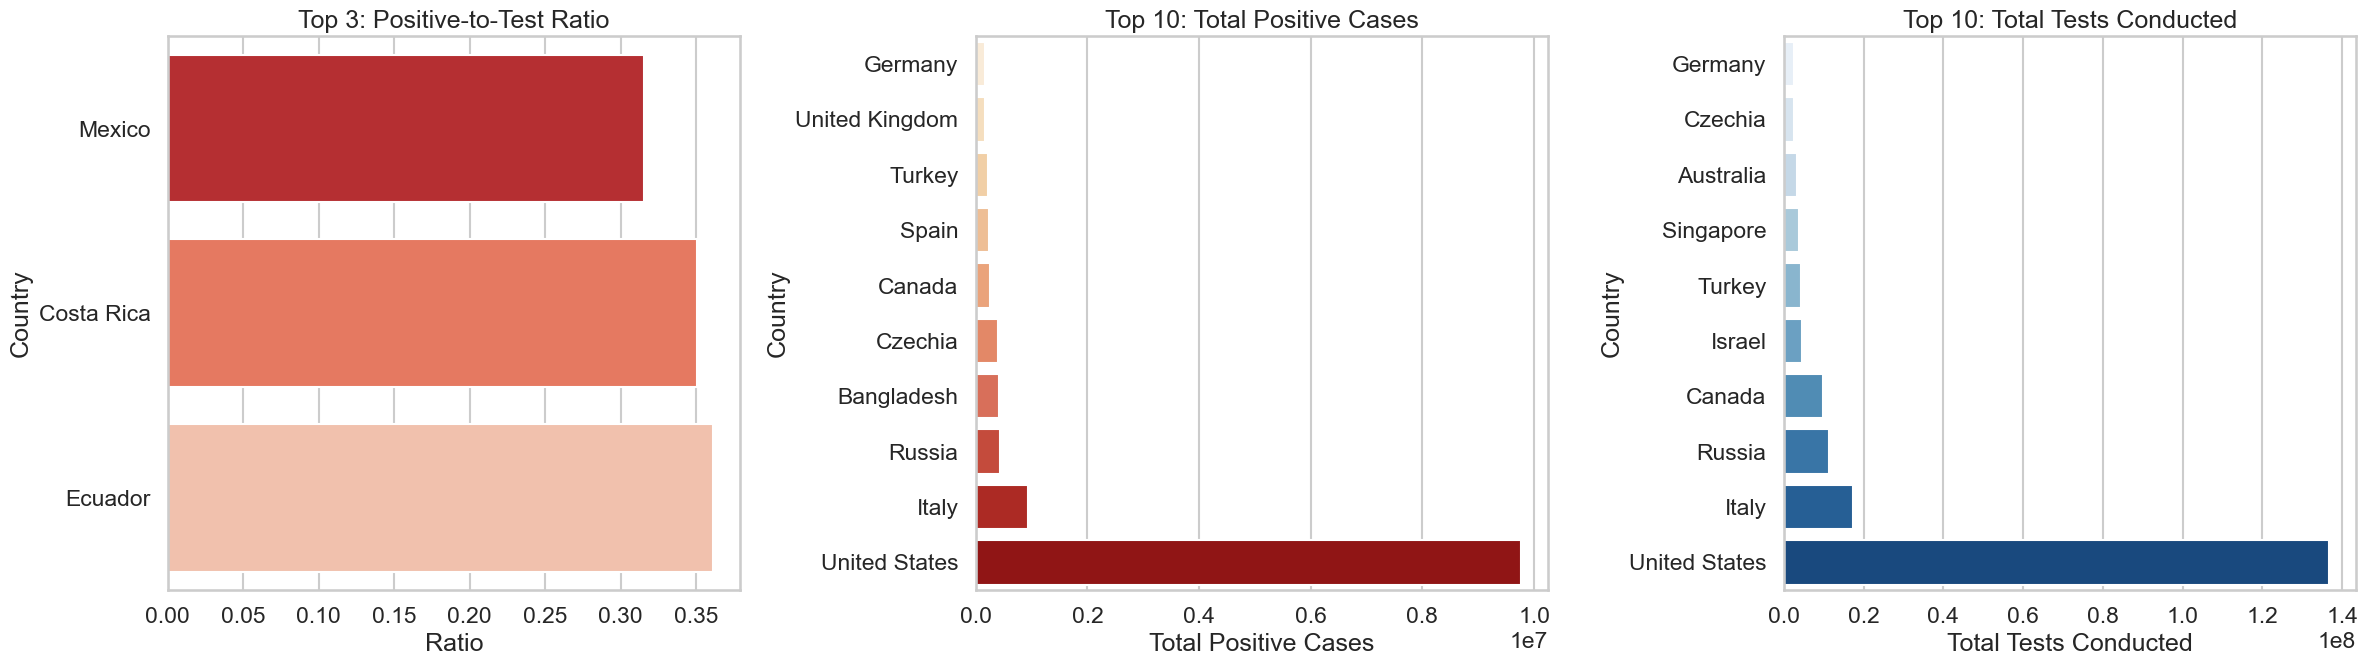

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# 6.1 Top 3 countries by positive-to-test ratio
ratio_plot = top_3_ratio_countries.sort_values("positive_to_test_ratio", ascending=True)
sns.barplot(
    data=ratio_plot,
    x="positive_to_test_ratio",
    y="country",
    hue="country",
    palette="Reds_r",
    legend=False,
    ax=axes[0]
)
axes[0].set_title("Top 3: Positive-to-Test Ratio")
axes[0].set_xlabel("Ratio")
axes[0].set_ylabel("Country")

# 6.2 Top 10 countries by total positive cases
positive_plot = top_10_positive_countries.sort_values("total_positive_cases", ascending=True)
sns.barplot(
    data=positive_plot,
    x="total_positive_cases",
    y="country",
    hue="country",
    palette="OrRd",
    legend=False,
    ax=axes[1]
)
axes[1].set_title("Top 10: Total Positive Cases")
axes[1].set_xlabel("Total Positive Cases")
axes[1].set_ylabel("Country")

# 6.3 Top 10 countries by total tests conducted
tests_plot = top_10_tested_countries.sort_values("total_tests_conducted", ascending=True)
sns.barplot(
    data=tests_plot,
    x="total_tests_conducted",
    y="country",
    hue="country",
    palette="Blues",
    legend=False,
    ax=axes[2]
)
axes[2].set_title("Top 10: Total Tests Conducted")
axes[2].set_xlabel("Total Tests Conducted")
axes[2].set_ylabel("Country")

plt.tight_layout()
plt.show()

## 4) Engineer Positivity Metrics

Create cumulative and daily positivity rates, then rank countries by latest cumulative positivity.

In [ ]:
df = df.sort_values(["country", "date"]).copy()

df["positivity_rate_cumulative"] = (df["positive"] / df["total_tested"]) * 100
df["positivity_rate_daily"] = (df["daily_positive"] / df["daily_tested"]) * 100

# Keep rates in sensible bounds
df.loc[(df["positivity_rate_cumulative"] < 0) | (df["positivity_rate_cumulative"] > 100), "positivity_rate_cumulative"] = np.nan
df.loc[(df["positivity_rate_daily"] < 0) | (df["positivity_rate_daily"] > 100), "positivity_rate_daily"] = np.nan

latest_by_country = (
    df.groupby("country", as_index=False)
      .apply(lambda x: x.sort_values("date").tail(1))
      .reset_index(drop=True)
)

# Reliability filter to avoid tiny-denominator distortions
MIN_TEST_THRESHOLD = 10000
ranked = (
    latest_by_country[latest_by_country["total_tested"] >= MIN_TEST_THRESHOLD]
    .dropna(subset=["positivity_rate_cumulative"])
    .sort_values("positivity_rate_cumulative", ascending=False)
    .reset_index(drop=True)
)

display(ranked[["country", "date", "positive", "total_tested", "positivity_rate_cumulative"]].head(15))

## 5) Supporting Trend Analysis

Compute 7-day positivity trends for countries with the highest cumulative positivity.

In [ ]:
daily = df.copy()

daily["daily_positivity_7d_avg"] = (
    daily.groupby("country")["positivity_rate_daily"]
         .transform(lambda s: s.rolling(7, min_periods=3).mean())
)

top_countries = ranked.head(10)["country"].tolist()
trend_df = daily[daily["country"].isin(top_countries)].copy()

print("Countries in ranking set:", ranked['country'].nunique())
print("Countries in top trend view:", len(top_countries))
display(trend_df[["country", "date", "positivity_rate_daily", "daily_positivity_7d_avg"]].tail(20))

## 6) Final Rankings for the Question

Return the final country ranking by latest cumulative positivity rate.

In [ ]:
top_n = 20
final_ranking = ranked[["country", "date", "positive", "total_tested", "positivity_rate_cumulative"]].head(top_n).copy()
final_ranking["positivity_rate_cumulative"] = final_ranking["positivity_rate_cumulative"].round(2)

print(f"Top {top_n} countries with the highest positive-to-tested ratio (minimum tests = {MIN_TEST_THRESHOLD:,})")
display(final_ranking)

In [ ]:
summary_stats = ranked["positivity_rate_cumulative"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95]).round(2)
print("Distribution of cumulative positivity rates (%) across countries in the ranking set:")
display(summary_stats.to_frame(name="positivity_rate_cumulative"))

## 7) Visualize Results

Build visuals that directly support the positivity-rate ranking interpretation.

In [ ]:
plot_df = final_ranking.sort_values("positivity_rate_cumulative", ascending=True)

fig, ax = plt.subplots(figsize=(14, 9))
sns.barplot(data=plot_df, x="positivity_rate_cumulative", y="country", palette="Reds_r", ax=ax)
ax.xaxis.set_major_formatter(PercentFormatter(100))
ax.set_title("Top Countries by Positive Cases Relative to Tests (Cumulative)")
ax.set_xlabel("Positivity Rate (%)")
ax.set_ylabel("Country")
plt.tight_layout()
plt.show()

In [ ]:
scatter_df = ranked.head(50).copy()

fig, ax = plt.subplots(figsize=(14, 7))
sns.scatterplot(
    data=scatter_df,
    x="total_tested",
    y="positive",
    size="positivity_rate_cumulative",
    hue="positivity_rate_cumulative",
    palette="rocket_r",
    sizes=(40, 400),
    alpha=0.75,
    ax=ax
)
ax.set_title("Positive Cases vs Total Tests (Top 50 by Positivity)")
ax.set_xlabel("Total Tested")
ax.set_ylabel("Positive Cases")
plt.tight_layout()
plt.show()

In [ ]:
# Optional choropleth by cumulative positivity rate
if PLOTLY_AVAILABLE:
    map_df = ranked.dropna(subset=["positivity_rate_cumulative"]).copy()
    fig = px.choropleth(
        map_df,
        locations="country",
        locationmode="country names",
        color="positivity_rate_cumulative",
        hover_name="country",
        color_continuous_scale="Reds",
        title="Latest Cumulative Positivity Rate by Country"
    )
    fig.show()
else:
    print("Plotly is not available; skipping choropleth map.")

## 8) Build a Reproducible Data Export Pipeline

Export cleaned data, rankings, and trend outputs used in this positivity analysis.

In [ ]:
output_dir = Path(r"c:\Users\O25002\projects\hackathon\hackathon-python-data-eng-MixCodes\outputs\covid_testing")
output_dir.mkdir(parents=True, exist_ok=True)

# Export tabular outputs
daily.to_csv(output_dir / "covid_testing_daily_cleaned.csv", index=False)
ranked.to_csv(output_dir / "covid_testing_country_positivity_ranking.csv", index=False)
final_ranking.to_csv(output_dir / "covid_testing_top20_positivity.csv", index=False)
trend_df.to_csv(output_dir / "covid_testing_top_positivity_trends.csv", index=False)

# Parquet export if engine exists
try:
    daily.to_parquet(output_dir / "covid_testing_daily_cleaned.parquet", index=False)
    parquet_msg = "Parquet export succeeded."
except Exception as ex:
    parquet_msg = f"Parquet export skipped ({ex})."

# Save one figure artifact reproducibly
fig, ax = plt.subplots(figsize=(10, 8))
top10 = final_ranking.head(10).sort_values("positivity_rate_cumulative")
sns.barplot(data=top10, x="positivity_rate_cumulative", y="country", palette="Reds_r", ax=ax)
ax.xaxis.set_major_formatter(PercentFormatter(100))
ax.set_title("Top 10 Countries by Cumulative Positivity Rate")
ax.set_xlabel("Positivity Rate (%)")
ax.set_ylabel("Country")
plt.tight_layout()
fig_path = output_dir / "top10_cumulative_positivity.png"
fig.savefig(fig_path, dpi=150)
plt.close(fig)

print(f"Outputs written to: {output_dir}")
print(parquet_msg)
print(f"Saved plot: {fig_path}")